#### imports

In [1]:
import signac
import os
import sys
import pandas as pd
import shutil
import nglview as nv
import MDAnalysis as mda
import numpy as np
import matplotlib.cm as cm
import itertools
import pyarrow.parquet as pq

In [2]:
path_git='../../../cascade_computing' #todo - path to git
sys.path.append(path_git)
print(os.path.exists(os.path.join(path_git, 'src')))

True


In [3]:
from src.compute.signac import sgnc as sgnc
from src.compute.utils import toolbox_plots as ptools
from src.compute.utils import toolbox_normalization as ntools

In [4]:
p_name='MUT16_FFR_atm_analysis_part' 
path=path_git+'/examples' 
project_path= path +'/' + p_name

In [5]:
project= sgnc.MyProject.get_project(project_path)
project

,sp.mols,sp.n_mols,sp.geo_mols,sp.replica_index,sp.structure_index,doc.domains,doc.output_path,doc.top,doc.top_mix,doc.top_org,...,doc.res_org_prob,doc.res_org_freq,doc.res_org_perc,doc.struc_id_prob,doc.struc_id_freq,doc.struc_id_perc,doc.res_dom_prob,doc.res_dom_freq,doc.res_dom_perc,doc.data_path
54544235add59ef9295f39739c202cb5,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,4,0,[],/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...
31fdac587cc5c5717a8739580694a49c,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,10,0,[],/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...
a3a724f3dd192659771f08027a756af8,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,8,0,[],/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...


#### connect data (choose dataset)

In [6]:
#connect data for lifetimes
for job in project:
    job.doc.data_path=job.path+'/results_files_lifetimes'
    job.doc.contact_path=job.doc.data_path
    job.doc.results_path=job.doc.data_path

project.run(progress=True,num_passes=1, order="by-job", names=['connecting_data'])#, jobs=[job])

  0%|          | 0/3 [00:00<?, ?it/s]

/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/workspace/54544235add59ef9295f39739c202cb5/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_54544235add59ef9295f39739c202cb5
gro True pdb True xtc False tcl True traj_meta True
/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/workspace/31fdac587cc5c5717a8739580694a49c/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_31fdac587cc5c5717a8739580694a49c
gro True pdb True xtc False tcl True traj_meta True
/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/workspace/a3a724f3dd192659771f08027a756af8/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_a3a724f3dd192659771f08027a756af8
gro True pdb True xtc False tcl True traj_meta True


In [7]:
#connect data for frequencies
#for job in project:
#    job.doc.data_path=job.path+'/results_files'
#    job.doc.contact_path=job.doc.data_path
#    job.doc.results_path=job.doc.data_path

#project.run(progress=True,num_passes=1, order="by-job", names=['connecting_data'])#, jobs=[job])

#### choose a single job

In [8]:
job = project.open_job(id='a3a724f3dd192659771f08027a756af8')

#### load contact data

In [9]:
#available files

#job.document['gro']
#job.document['pdb']
#job.document['tcl'] 

#job.document['contact_record'] 
#job.document['contact_meta'] 

#job.document['res_type_freq']
#job.document['res_type_perc']  

In [10]:
job.document['output_path']

'/lustre/miifs01/project/m2_trr146/kugaurav/MUT16_FFR_atomistic/replica_8/dynamics'

In [11]:
job.document['res_type_freq']

'/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/workspace/a3a724f3dd192659771f08027a756af8/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_a3a724f3dd192659771f08027a756af8_res_type_time_count_pivot.parquet'

In [12]:
job.document['contact_meta'] 

'/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/workspace/a3a724f3dd192659771f08027a756af8/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_a3a724f3dd192659771f08027a756af8_contacts_res_meta.parquet'

In [13]:
job.document['pdb']

'/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/workspace/a3a724f3dd192659771f08027a756af8/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_a3a724f3dd192659771f08027a756af8_pi_clean.pdb'

In [14]:
job.document['contact_record']

'/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/workspace/a3a724f3dd192659771f08027a756af8/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_a3a724f3dd192659771f08027a756af8_contacts_only_t.parquet'

#### load contact record

In [15]:
#check available data
from fastparquet import ParquetFile
pf = ParquetFile(job.document['contact_record'])
print(pf.columns)

['res_a', 'res_b', 'frame_d2t', 'len_contacts', 'mol_ind_a', 'res_type_a', 'struc_id_a', 'prot_a', 'res_org_a', 'mol_ind_b', 'res_type_b', 'struc_id_b', 'prot_b', 'res_org_b', 'percistance_times', 'avg_persistence', 'median_persistence']


In [16]:
#choose columns 
l_columns=['res_a', 'res_b','frame_d2t', 'len_contacts', 'mol_ind_a', 'res_type_a', 'struc_id_a', 'prot_a', 'res_org_a', 'mol_ind_b', 'res_type_b', 'struc_id_b', 'prot_b', 'res_org_b', 'percistance_times', 'avg_persistence', 'median_persistence']

In [17]:
#load data (remove .slice to load the full record)
contacts = pq.read_table(
    job.document['contact_record'], 
    columns=l_columns
).slice(0, 100).to_pandas()
contacts.head()

,res_a,res_b,frame_d2t,len_contacts,mol_ind_a,res_type_a,struc_id_a,prot_a,res_org_a,mol_ind_b,res_type_b,struc_id_b,prot_b,res_org_b,percistance_times,avg_persistence,median_persistence
0,5637,8389,"[6253, 6254, 6255, 6256, 6257, 6258, 6259, 626...",239,32,MET,32,MUT16,905,48,MET,48,MUT16,905,"[24, 214, 1]",79.666667,24.0
1,5639,8388,"[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 3...",6143,32,VAL,32,MUT16,907,48,ARG,48,MUT16,904,"[99, 55, 851, 1023, 1003, 992, 985, 946, 180, 9]",614.300000,898.5
2,5639,8389,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",7914,32,VAL,32,MUT16,907,48,MET,48,MUT16,905,[7914],7914.000000,7914.0
3,5641,8387,"[226, 227, 228, 229, 230, 231, 232, 233, 234, ...",7483,32,TYR,32,MUT16,909,48,ASP,48,MUT16,903,"[880, 3183, 3243, 177]",1870.750000,2031.5
4,5641,8388,"[172, 173, 174, 175, 176, 177, 178, 179, 180, ...",5364,32,TYR,32,MUT16,909,48,ARG,48,MUT16,904,"[2087, 2394, 882, 1]",1341.000000,1484.5


#### load system metadata

In [18]:
u1=mda.Universe(job.document['pdb'])
view_l=nv.show_mdanalysis(u1.residues)
view_l.add_unitcell()
view_l

NGLWidget()

In [19]:
contact_meta=pd.read_parquet(job.document['contact_meta'])
contact_meta.head()

,res,mol_ind,res_dom,res_type,struc_id,prot,res_org
0,1,0,NaN,VAL,0,MUT16,773
1,2,0,NaN,ASN,0,MUT16,774
2,3,0,NaN,GLN,0,MUT16,775
3,4,0,NaN,GLN,0,MUT16,776
4,5,0,NaN,GLN,0,MUT16,777


In [20]:
job.data['df_sys_domains']

,prot,struc_id,unit,min,max
0,MUT16,0,A,1,172
1,MUT16,1,A,173,344
2,MUT16,2,A,345,516
3,MUT16,3,A,517,688
4,MUT16,4,A,689,860
...,...,...,...,...,...
60,MUT16,60,A,10321,10492
61,MUT16,61,A,10493,10664
62,MUT16,62,A,10665,10836
63,MUT16,63,A,10837,11008


#### contact frequency

In [21]:
job.document['res_type_freq']

'/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/workspace/a3a724f3dd192659771f08027a756af8/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_a3a724f3dd192659771f08027a756af8_res_type_time_count_pivot.parquet'

In [22]:
#contact frequency
time_contacts_prot_res_type = ntools.calc_frequency(pd.read_parquet(job.document['res_type_freq']).astype(float))
time_contacts_prot_res_type

res_type_b,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL
res_type_a,,,,,,,,,,,,,,,,,,,,
ALA,0.000204,0.000446,0.001970,0.000435,0.000010,0.002436,0.000177,0.0,0.000862,0.000216,1.412997e-05,0.000105,0.000287,0.000887,0.002032,0.000646,7.013991e-05,0.0,0.002087,0.000429
ARG,0.000446,0.001582,0.007067,0.005117,0.000347,0.006457,0.001978,0.0,0.004494,0.000580,3.547116e-04,0.000219,0.001039,0.002658,0.004936,0.004138,4.619252e-04,0.0,0.005331,0.000845
ASN,0.001970,0.007067,0.018461,0.005646,0.000651,0.024535,0.002820,0.0,0.011457,0.002428,7.895366e-04,0.000719,0.002327,0.005570,0.016485,0.011490,1.372007e-03,0.0,0.016537,0.003584
ASP,0.000435,0.005117,0.005646,0.001997,0.000187,0.007352,0.000641,0.0,0.003619,0.000340,2.715654e-04,0.000591,0.000492,0.001604,0.003201,0.004367,4.816376e-04,0.0,0.003455,0.000993
CYS,0.000010,0.000347,0.000651,0.000187,0.000036,0.000773,0.000182,0.0,0.000450,0.000083,1.317775e-06,0.000012,0.000053,0.000300,0.000623,0.000285,3.619367e-05,0.0,0.000705,0.000077
GLN,0.002436,0.006457,0.024535,0.007352,0.000773,0.028139,0.002458,0.0,0.013877,0.003164,7.907009e-04,0.000749,0.002521,0.008328,0.021878,0.012491,1.860562e-03,0.0,0.021493,0.004944
GLU,0.000177,0.001978,0.002820,0.000641,0.000182,0.002458,0.000415,0.0,0.001369,0.000166,8.653538e-05,0.000264,0.000290,0.000440,0.001203,0.001719,2.275734e-04,0.0,0.001322,0.000439
GLY,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000
HIS,0.000862,0.004494,0.011457,0.003619,0.000450,0.013877,0.001369,0.0,0.007279,0.001585,5.243841e-04,0.000603,0.002205,0.005653,0.011069,0.006695,1.157119e-03,0.0,0.011520,0.002218


./plot


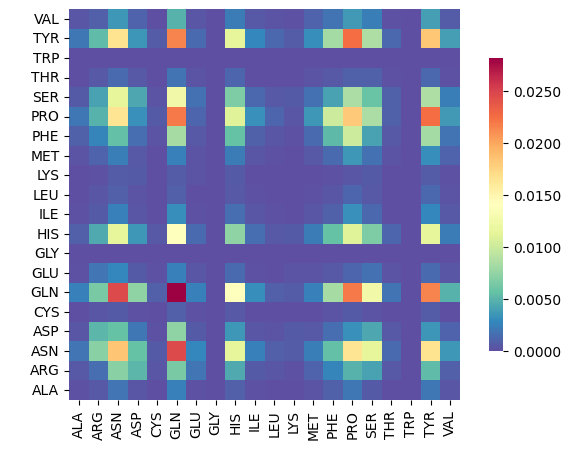

In [23]:
ptools.plot_df(time_contacts_prot_res_type)

### normalized contact frequency by residue abundance

In [24]:
#check abundance of amino acids
res_types_df=ntools.eval_aa_table(contact_meta, name='MUT16_chain')
res_types_df.head()

/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/../../../cascade_computing/src/compute/utils/toolbox_normalization.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.groupby(['struc_id','res_type'])
/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/../../../cascade_computing/src/compute/utils/toolbox_normalization.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.groupby(['prot','res_type'])


prot,MUT16,total,MUT16_chain
res_type,,,
ALA,260.0,260.0,4.0
ARG,390.0,390.0,6.0
ASN,1430.0,1430.0,22.0
ASP,520.0,520.0,8.0
CYS,65.0,65.0,1.0


In [25]:
matrix = np.outer(res_types_df['MUT16_chain'], res_types_df['MUT16_chain'])
MUT16_MUT16_int_res_types = pd.DataFrame(matrix, index=res_types_df.index, columns=res_types_df.index)

In [26]:
#normalize frequency
norm_freq_prot_res_type=ntools.normalize_frequency(time_contacts_prot_res_type,MUT16_MUT16_int_res_types)

./plot


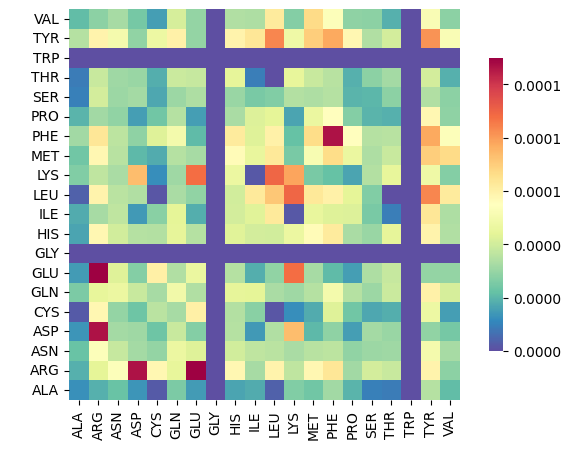

In [27]:
ptools.plot_df(norm_freq_prot_res_type)

#### contact lifetime distribution

In [28]:
job.document['res_type_perc']

'/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_part/workspace/a3a724f3dd192659771f08027a756af8/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_a3a724f3dd192659771f08027a756af8_res_type_list_percistance_distribution_pivot.parquet'

In [29]:
res_type_perc = pd.read_parquet(job.document['res_type_perc'])
res_type_perc

res_type_b,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL
res_type_a,,,,,,,,,,,,,,,,,,,,
ALA,"[105, 52, 118, 1, 11, 111, 1, 1686, 259, 831, ...","[113, 9, 148, 13, 102, 19, 92, 26, 25, 1, 99, ...","[11, 10, 22, 20, 277, 305, 7009, 87, 984, 990,...","[7914, 43, 849, 48, 848, 989, 1, 4981, 82, 429...","[1, 6, 19, 1, 101, 30, 1, 21, 9, 7, 40, 415, 2...","[335, 322, 990, 178, 24, 800, 991, 176, 22, 14...","[486, 13, 311, 522, 554, 166, 923, 119, 1, 15,...",[],"[86, 77, 192, 1, 1, 31, 1, 1573, 29, 37, 6, 20...","[79, 580, 88, 21, 4854, 1265, 613, 854, 98, 40...","[121, 478, 95, 92, 99, 94, 82, 81, 33, 3, 35, ...","[4627, 1, 527, 864, 597, 376, 312, 28, 118, 63...","[5, 7914, 15, 1, 7667, 2, 15, 7, 6, 75, 237, 8...","[211, 48, 44, 1, 13, 330, 16, 27, 52, 108, 1, ...","[1116, 6730, 2452, 2, 267, 53, 17, 22, 89, 2, ...","[11, 17, 338, 344, 59, 183, 304, 20, 1, 1, 791...","[141, 1, 1, 32, 1, 7903, 1964, 102, 99, 125, 9...",[],"[126, 59, 100, 105, 8, 152, 169, 76, 125, 30, ...","[1, 91, 248, 265, 13, 364, 77, 268, 168, 142, ..."
ARG,"[187, 235, 198, 47, 256, 1030, 5035, 298, 109,...","[7908, 72, 258, 696, 1, 245, 186, 239, 833, 23...","[1, 13, 30, 7, 56, 35, 33, 44, 150, 13, 11, 9,...","[7877, 149, 180, 7, 27, 197, 112, 804, 120, 57...","[354, 60, 145, 990, 71, 130, 116, 36, 454, 71,...","[11, 86, 35, 20, 53, 1, 200, 34, 17, 12, 27, 1...","[7920, 1249, 500, 9, 1034, 1422, 188, 106, 167...",[],"[52, 61, 62, 7892, 265, 184, 500, 572, 4453, 3...","[5502, 919, 936, 197, 7602, 296, 14, 1, 7903, ...","[17, 160, 1, 16, 5, 23, 6, 1, 398, 79, 245, 62...","[206, 381, 19, 131, 3, 194, 4, 1, 307, 26, 125...","[16, 4, 6, 5, 34, 1, 988, 992, 988, 3902, 98, ...","[173, 1, 172, 50, 150, 47, 141, 149, 168, 71, ...","[327, 748, 391, 136, 1, 98, 1, 227, 99, 143, 9...","[12, 115, 30, 1, 18, 26, 6, 255, 15, 63, 2, 79...","[65, 7920, 430, 5, 252, 243, 1, 22, 5, 94, 89,...",[],"[7900, 490, 567, 84, 918, 1, 638, 178, 7908, 3...","[1034, 851, 15, 63, 94, 81, 66, 24, 354, 137, ..."
ASN,"[26, 10, 50, 37, 1, 10, 135, 62, 67, 243, 260,...","[7920, 7920, 1, 45, 3, 73, 265, 98, 60, 46, 92...","[7292, 7920, 30, 966, 89, 43, 932, 1015, 990, ...","[143, 227, 101, 2459, 1, 1, 6, 8, 421, 39, 1, ...","[888, 402, 273, 252, 139, 24, 77, 357, 144, 34...","[7920, 103, 1, 26, 47, 15, 781, 99, 2, 99, 16,...","[7830, 544, 3555, 99, 3025, 87, 2093, 222, 142...",[],"[7821, 7917, 659, 992, 1076, 1009, 997, 996, 1...","[33, 41, 185, 1, 77, 76, 28, 31, 525, 133, 19,...","[424, 975, 717, 985, 2166, 86, 17, 19, 99, 33,...","[6, 20, 126, 33, 26, 10, 11, 53, 46, 1, 39, 40...","[272, 72, 69, 1, 4, 13, 10, 2, 7, 57, 4, 7, 12...","[156, 8, 1, 164, 6, 4, 131, 58, 7, 18, 52, 46,...","[1251, 19, 627, 212, 920, 518, 46, 651, 636, 5...","[4628, 963, 1, 7920, 9, 1, 952, 1100, 3728, 57...","[99, 1, 7918, 25, 99, 455, 928, 1, 993, 990, 9...",[],"[1889, 95, 4628, 1, 165, 1, 136, 3, 360, 950, ...","[1, 17, 6, 6, 6, 112, 6, 5, 3, 10, 5, 3228, 10..."
ASP,"[69, 429, 4305, 51, 32, 60, 28, 98, 94, 16, 56...","[7920, 3010, 49, 7818, 223, 223, 1035, 936, 58...","[1, 5367, 3171, 4554, 109, 14, 170, 158, 75, 5...","[42, 143, 16, 16, 118, 326, 889, 69, 832, 4293...","[67, 260, 879, 266, 212, 654, 800, 186, 982, 1...","[149, 6174, 1073, 178, 293, 990, 1, 177, 3, 10...","[1243, 12, 1851, 163, 5351, 54, 538, 348, 658,...",[],"[1358, 461, 1032, 3882, 297, 1421, 5731, 4459,...","[4716, 10, 100, 251, 105, 89, 27, 3, 96, 302, ...","[42, 659, 471, 6, 40, 21, 7, 52, 31, 23, 8, 14...","[10, 526, 3, 516, 281, 655, 30, 715, 18, 230, ...","[155, 436, 302, 983, 991, 1404, 78, 245, 463, ...","[2499, 2147, 3064, 58, 108, 5109, 184, 1, 109,...","[64, 1, 58, 993, 204, 570, 806, 98, 82, 430, 4...","[184, 832, 4262, 1027, 178, 562, 1582, 3512, 1...","[1, 5286, 1787, 65, 396, 688, 331, 157, 70, 46...",[],"[56, 221, 2, 990, 997, 990, 1, 993, 990, 137, ...","[789, 670, 203, 904, 971, 987, 978, 424, 400, ..."
CYS,"[40, 415, 28, 17, 109, 94, 99, 95, 93, 102, 60...","[7820, 584, 99, 1, 100, 98, 1, 99, 1,

/var/folders/pk/ly17dvss3_l5y0qhg05cqy2w0000gn/T/ipykernel_35562/4228384833.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_pairs))


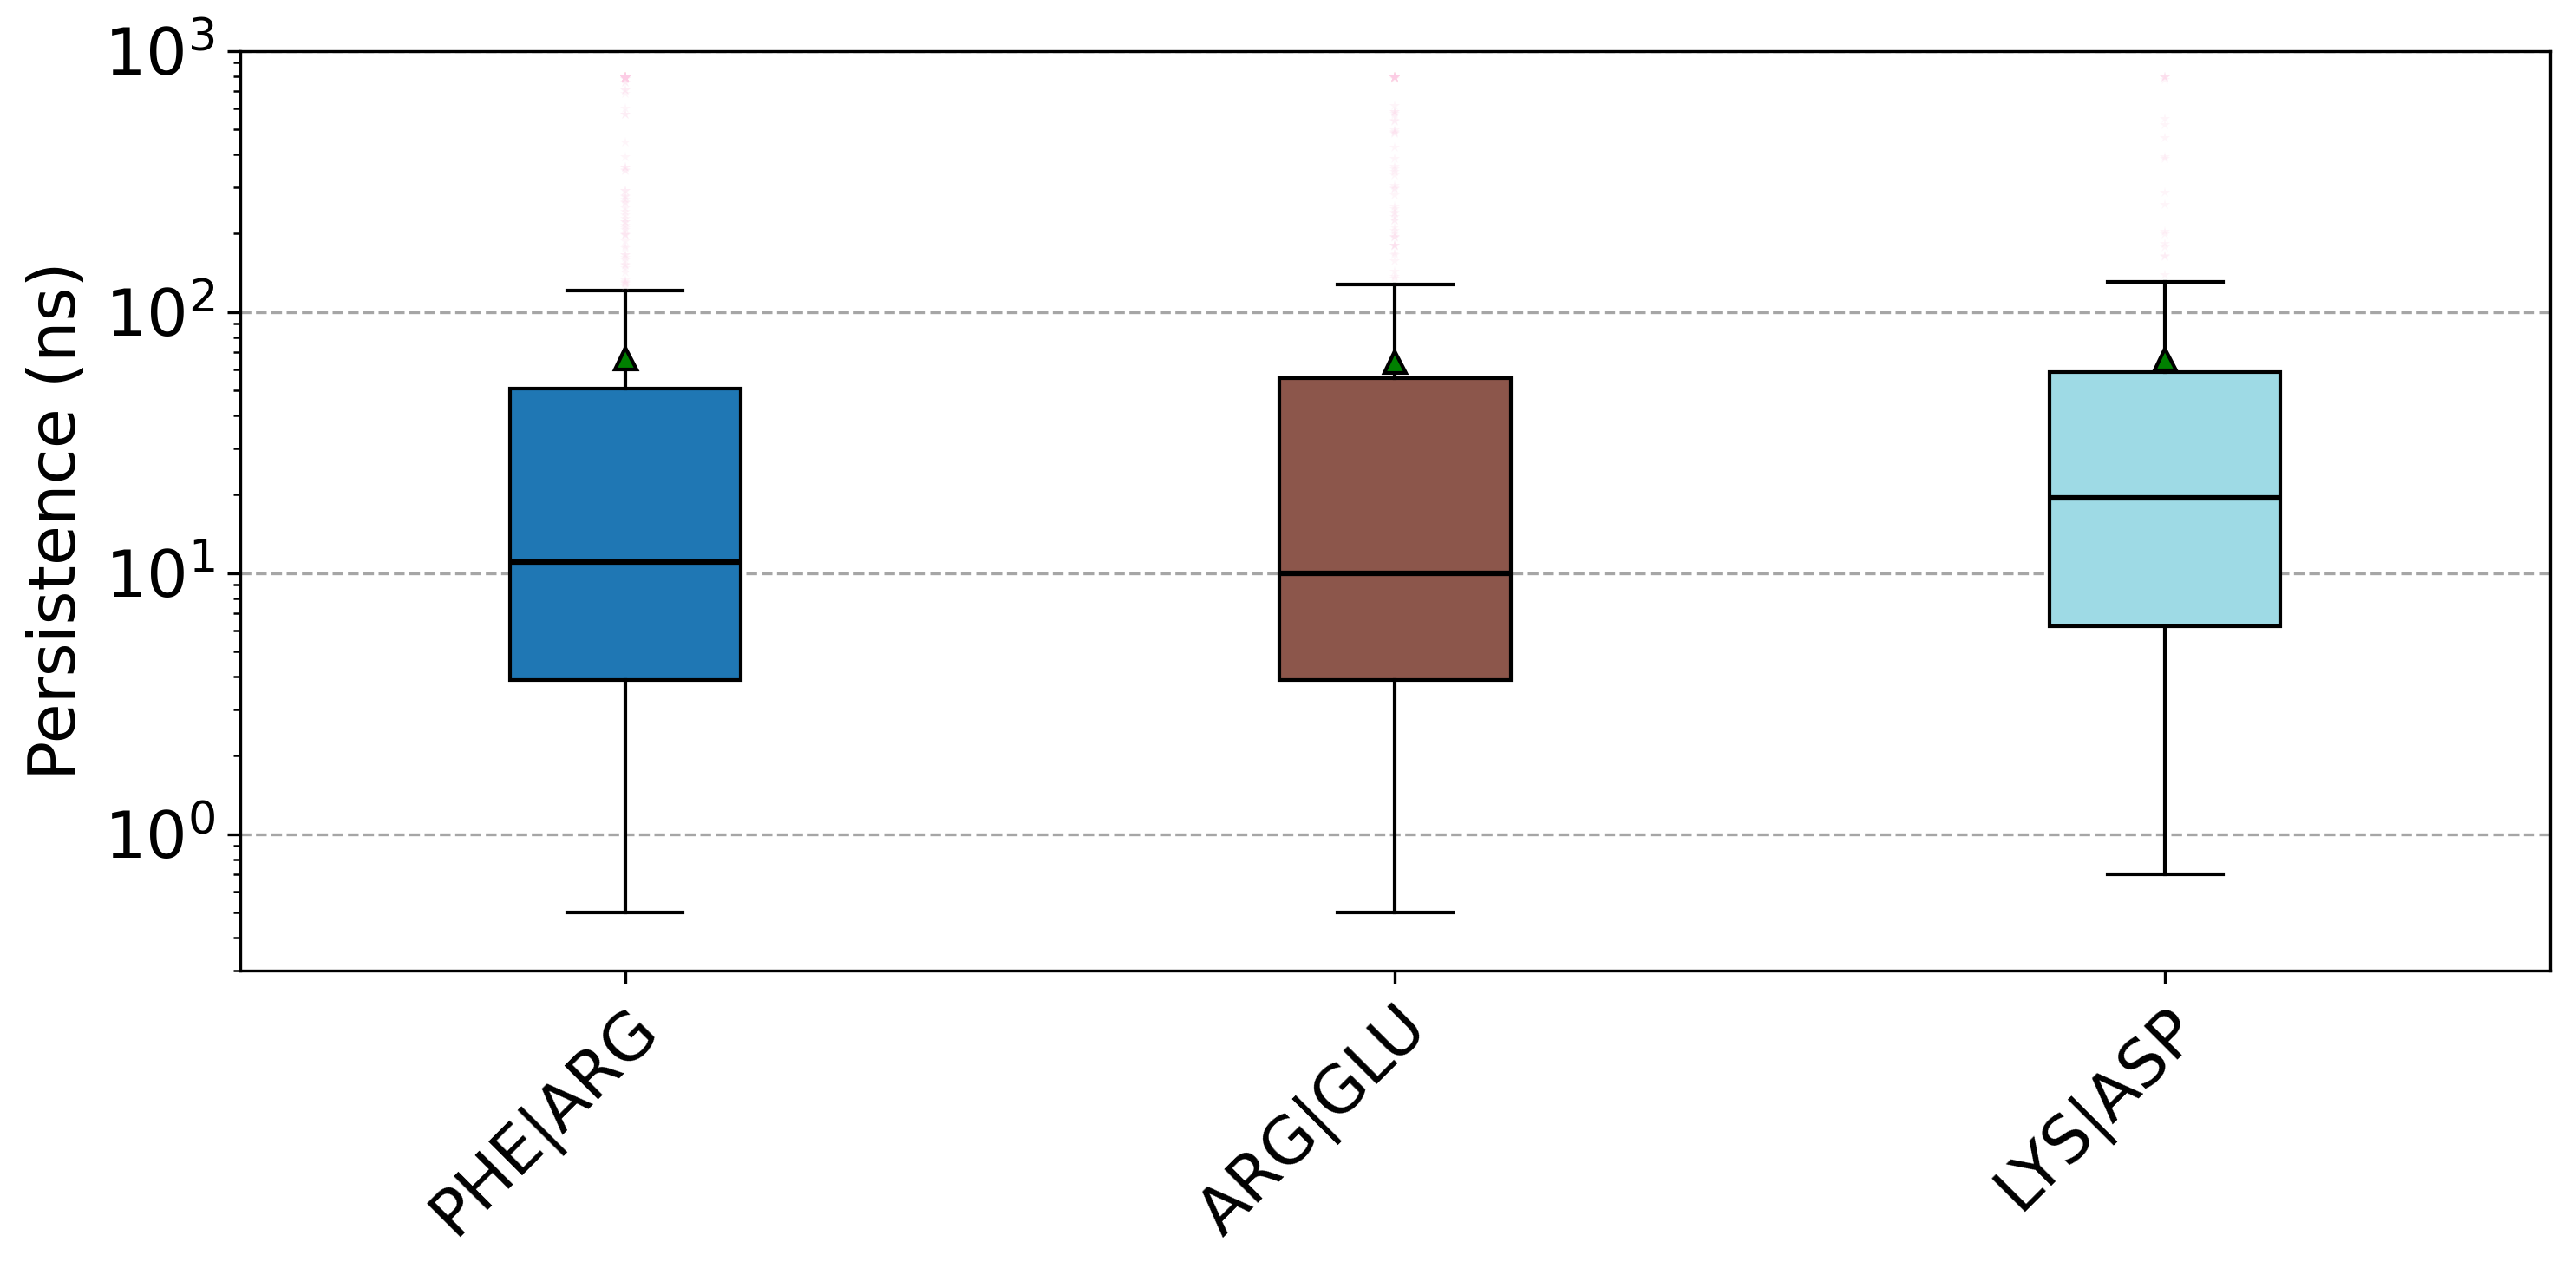

In [30]:
#what do plot - choose pairs
pairs=[["PHE","ARG"],["ARG","GLU"],["LYS","ASP"]]

output_filename = '' 
val_title=''
query=["MUT16","MUT16"]
subquery=np.array(pairs)


mat=ntools.query_slice(query, subquery,res_type_perc )
#mat=res_type_perc
#filter
mat_filtered = mat.map(
lambda lst: [x for x in lst if x >= 5] if isinstance(list(lst), list) else []
)
#data pairs for labeling with color map
all_pairs = list(itertools.product(mat_filtered.index, mat_filtered.columns))
joined_all_pairs = ["_".join(map(str, l)) for l in all_pairs]

unique_pairs = list(dict.fromkeys(joined_all_pairs))

import matplotlib.cm as cm
cmap = cm.get_cmap("tab20", len(unique_pairs))
pair_to_color = {p: cmap(i) for i, p in enumerate(unique_pairs)}

# pass the DICT (not the list)
color_map = pair_to_color

ptools.plot_boxplots_whisker_scaled(mat_filtered, output_filename, color_map,val_title, scale=0.1, pairs=pairs)

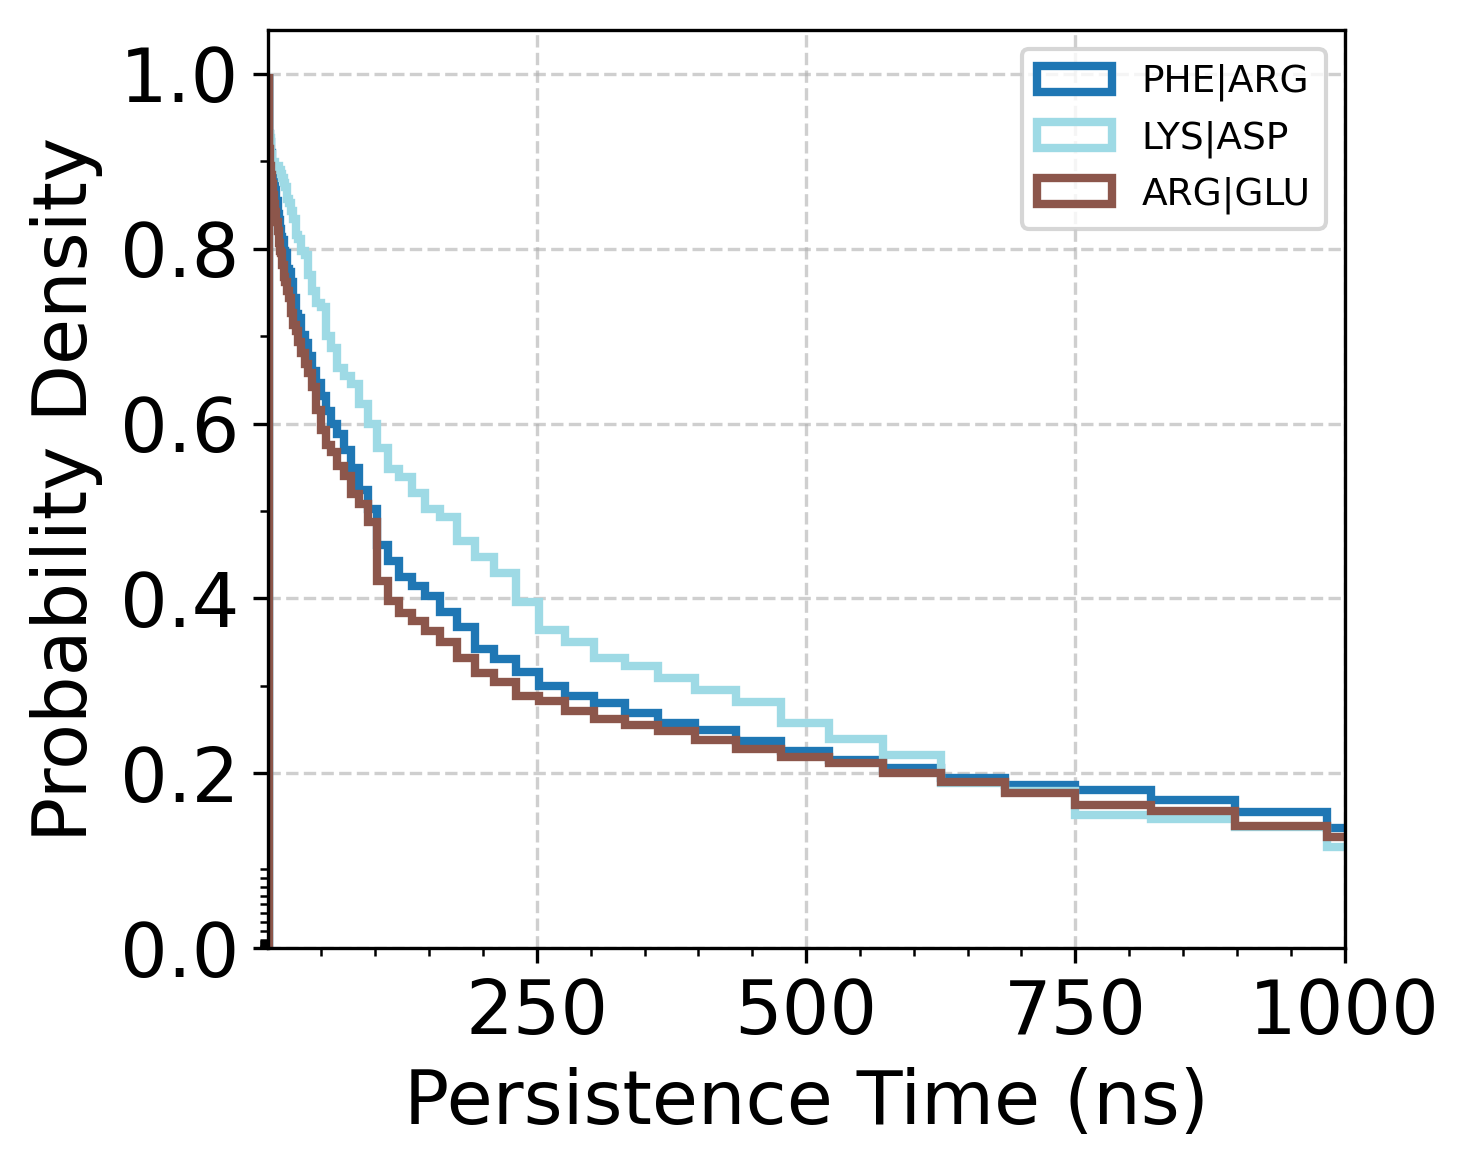

In [31]:
mat_filtered = res_type_perc.map(
lambda lst: [x for x in lst if x >= 0] if isinstance(list(lst), list) else []
)
#data pairs for labeling with color map
all_pairs = list(itertools.product(mat_filtered.index, mat_filtered.columns))
joined_all_pairs = ["_".join(map(str, l)) for l in all_pairs]

unique_pairs = list(dict.fromkeys(joined_all_pairs))

ptools.plot_hist(mat_filtered, output_filename, color_map,title=val_title,pairs=pairs)